# 个人作业1：桌游复杂度与玩家评分的量化关系
## —— 基于 BoardGameGeek 数据
### 大数据处理技术课程 — 2025-2026第二学期
**授课教师：周孟莹** | **数据集：BGG BoardGameGeek (TidyTuesday 2019)**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
import os
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

print("Environment ready - Python + Pandas + Matplotlib + Seaborn + Scikit-learn")
print("Course: Chapter3 High-dimensional Table Data, Chapter4 Time Series")
print("Data source: BGG BoardGameGeek via TidyTuesday 2019")

Environment ready - Python + Pandas + Matplotlib + Seaborn + Scikit-learn
Course: Chapter3 High-dimensional Table Data, Chapter4 Time Series
Data source: BGG BoardGameGeek via TidyTuesday 2019


In [2]:
# === Step 1: Data Loading ===
# BGG dataset: 20k+ board games with ratings, mechanics, categories, playing time
# Source: TidyTuesday 2019 (github.com/rfordatascience/tidytuesday)

df = pd.read_csv('data/bgg_board_games.csv')
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
print(f"\nYear range: {df['year_published'].min():.0f} - {df['year_published'].max():.0f}")
print(f"Games with ratings: {df['users_rated'].gt(0).sum():,}")
display(df.head(3))

Dataset shape: 10,532 rows x 22 columns
Columns: ['game_id', 'description', 'image', 'max_players', 'max_playtime', 'min_age', 'min_players', 'min_playtime', 'name', 'playing_time', 'thumbnail', 'year_published', 'artist', 'category', 'compilation', 'designer', 'expansion', 'family', 'mechanic', 'publisher', 'average_rating', 'users_rated']

Year range: 1950 - 2016
Games with ratings: 10,532


,game_id,description,image,max_players,max_playtime,min_age,min_players,min_playtime,name,playing_time,...,artist,category,compilation,designer,expansion,family,mechanic,publisher,average_rating,users_rated
0,1,Die Macher is a game about seven sequential po...,//cf.geekdo-images.com/images/pic159509.jpg,5,240,14,3,240,Die Macher,240,...,Marcus Gschwendtner,"Economic,Negotiation,Political",NaN,Karl-Heinz Schmiel,NaN,"Country: Germany,Valley Games Classic Line","Area Control / Area Influence,Auction/Bidding,...","Hans im Glück Verlags-GmbH,Moskito Spiele,Vall...",7.66508,4498
1,2,Dragonmaster is a trick-taking card game based...,//cf.geekdo-images.com/images/pic184174.jpg,4,30,12,3,30,Dragonmaster,30,...,Bob Pepper,"Card Game,Fantasy",NaN,"G. W. ""Jerry"" D'Arcey",NaN,Animals: Dragons,Trick-taking,"E.S. Lowe,Milton Bradley",6.60815,478
2,3,"Part of the Knizia tile-laying trilogy, Samura...",//cf.geekdo-images.com/images/pic3211873.jpg,4,60,10,2,30,Samurai,60,...,Franz Vohwinkel,"Abstract Strategy,Medieval",NaN,Reiner Knizia,NaN,"Asian Theme,Country: Japan,Knizia tile-laying ...","Area Control / Area Influence,Hand Management,...","999 Games,ABACUSSPIELE,Astrel Games,Ceilikan J...",7.44119,12019


### Data Dictionary (BGG TidyTuesday 2019)

| Column | Type | Description | Course Reference |
|--------|------|-------------|------------------|
| game_id, name | ID/Text | Game identifier and title | — |
| year_published | Year | Publication year | Chapter3: Sequence data |
| average_rating | Float (1-10) | Average user rating | Continuous numerical (target) |
| users_rated | Int | Number of ratings | Popularity metric |
| mechanic | Text (comma-separated) | Game mechanics tags | High-dim categorical features |
| category | Text (comma-separated) | Game categories | High-dim categorical features |
| playing_time | Int (minutes) | Average playing time | Duration proxy |
| min_players, max_players | Int | Player count range | Player configuration |
| min_age | Int | Minimum recommended age | Complexity proxy |
| designer, publisher, artist | Text | Creator metadata | Categorical |


In [3]:
# === Step 2: Data Cleaning ===
# Following Chapter4 "Data Preprocessing" methodology (pp.9-13)

print("=== Data Cleaning (Chapter4 pp.9-13) ===")

# 1. Filter: meaningful ratings only (>= 30 users)
# "When missing proportion exceeds threshold, the information loses statistical meaning" (p.10)
before = len(df)
df = df[df['users_rated'] >= 30].copy()
print(f"1. Filtered users_rated >= 30: {before:,} -> {len(df):,} games")

# Filter out games with year_published = 0 (missing year)
before = len(df)
df = df[df['year_published'] > 0].copy()
print(f"2. Filtered valid year_published: {before:,} -> {len(df):,} games")

# 2. Missing value analysis
print(f"\n=== Missing Value Analysis ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
}).sort_values('Missing %', ascending=False)
display(missing_df[missing_df['Missing Count'] > 0])

# 3. Handle missing values
# Numeric: median fill (Chapter4 p.10)
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"  [{col}] filled with median {df[col].median():.1f}")

# Categorical: fill with 'Unknown' (Chapter4 p.10)
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna('Unknown', inplace=True)

print(f"\nRemaining missing: {df.isnull().sum().sum()}")
assert df.isnull().sum().sum() == 0

# 4. Rating range validation (should be 1-10)
rating_col = 'average_rating'
valid_rating = (df[rating_col] >= 1) & (df[rating_col] <= 10)
print(f"Rating outliers (<1 or >10): {(~valid_rating).sum()} rows")
df = df[valid_rating]

# 5. Year filter (before 2026)
valid_year = df['year_published'] <= 2026
print(f"Invalid years (>2026): {(~valid_year).sum()} rows")
df = df[valid_year]

# 6. Remove games with playing_time = 0 (likely data entry error)
valid_time = df['playing_time'] > 0
print(f"Zero playing_time: {(~valid_time).sum()} rows")
df = df[valid_time]

print(f"\nFinal dataset: {df.shape[0]:,} games, {df.shape[1]} columns")
df.head()

=== Data Cleaning (Chapter4 pp.9-13) ===
1. Filtered users_rated >= 30: 10,532 -> 10,532 games
2. Filtered valid year_published: 10,532 -> 10,532 games

=== Missing Value Analysis ===


,Missing Count,Missing %
compilation,10122,96.11
expansion,7780,73.87
family,2808,26.66
artist,2773,26.33
mechanic,950,9.02
designer,126,1.20
category,94,0.89
publisher,3,0.03
thumbnail,1,0.01
image,1,0.01



Remaining missing: 0
Rating outliers (<1 or >10): 0 rows
Invalid years (>2026): 0 rows
Zero playing_time: 350 rows

Final dataset: 10,182 games, 22 columns


,game_id,description,image,max_players,max_playtime,min_age,min_players,min_playtime,name,playing_time,...,artist,category,compilation,designer,expansion,family,mechanic,publisher,average_rating,users_rated
0,1,Die Macher is a game about seven sequential po...,//cf.geekdo-images.com/images/pic159509.jpg,5,240,14,3,240,Die Macher,240,...,Marcus Gschwendtner,"Economic,Negotiation,Political",Unknown,Karl-Heinz Schmiel,Unknown,"Country: Germany,Valley Games Classic Line","Area Control / Area Influence,Auction/Bidding,...","Hans im Glück Verlags-GmbH,Moskito Spiele,Vall...",7.66508,4498
1,2,Dragonmaster is a trick-taking card game based...,//cf.geekdo-images.com/images/pic184174.jpg,4,30,12,3,30,Dragonmaster,30,...,Bob Pepper,"Card Game,Fantasy",Unknown,"G. W. ""Jerry"" D'Arcey",Unknown,Animals: Dragons,Trick-taking,"E.S. Lowe,Milton Bradley",6.60815,478
2,3,"Part of the Knizia tile-laying trilogy, Samura...",//cf.geekdo-images.com/images/pic3211873.jpg,4,60,10,2,30,Samurai,60,...,Franz Vohwinkel,"Abstract Strategy,Medieval",Unknown,Reiner Knizia,Unknown,"Asian Theme,Country: Japan,Knizia tile-laying ...","Area Control / Area Influence,Hand Management,...","999 Games,ABACUSSPIELE,Astrel Games,Ceilikan J...",7.44119,12019
3,4,When you see the triangular box and the luxuri...,//cf.geekdo-images.com/images/pic285299.jpg,4,60,12,2,60,Tal der Könige,60,...,Unknown,Ancient,Unknown,Christian Beierer,Unknown,"Country: Egypt,Promotional Board Games","Action Point Allowance System,Area Control / A...",KOSMOS,6.60675,314
4,5,"In Acquire, each player strategically invests ...",//cf.geekdo-images.com/images/pic342163.jpg,6,90,12,3,90,Acquire,90,...,"Scott Okumura,Peter Whitley",Economic,Unknown,Sid Sackson,Unknown,3M Bookshelf Series,"Hand Management,Stock Holding,Tile Placement","3M,Avalon Hill,Avalon Hill (Hasbro),Dujardin,G...",7.35830,15195


In [4]:
# === Feature Engineering ===
# Create derived features for analysis

# 1. Log users_rated (popularity metric - right-skewed)
df['log_users_rated'] = np.log1p(df['users_rated'])

# 2. Playing time bins (duration categories)
time_bins = [0, 30, 60, 120, 99999]
time_labels = ['<30 min', '30-60 min', '60-120 min', '>120 min']
df['time_bin'] = pd.cut(df['playing_time'], bins=time_bins, labels=time_labels)

# 3. Age bins (complexity proxy - Chapter3 composite metrics)
age_bins = [0, 8, 12, 16, 999]
age_labels = ['Ages 0-8', 'Ages 8-12', 'Ages 12-16', 'Ages 16+']
df['age_bin'] = pd.cut(df['min_age'], bins=age_bins, labels=age_labels)

# 4. Mechanics count (mechanism diversity index)
df['mechanics_count'] = df['mechanic'].fillna('').str.split(',').apply(
    lambda x: len([i for i in x if i.strip() != ''])
)

# 5. Player count range
df['player_range'] = df['max_players'] - df['min_players']

# 6. Year bins (era classification)
year_bins = [1900, 1980, 1995, 2005, 2015, 2026]
year_labels = ['Pre-1980', '1980-1995', '1995-2005', '2005-2015', '2015+']
df['era'] = pd.cut(df['year_published'], bins=year_bins, labels=year_labels)

print("=== Derived Features ===")
print(f"  log_users_rated: popularity (log scale)")
print(f"  time_bin: duration category")
print(f"  age_bin: age recommendation category")
print(f"  mechanics_count: number of mechanics (mean={df['mechanics_count'].mean():.1f})")
print(f"  player_range: player count flexibility")
print(f"  era: publication era")
print(f"\nData ready for EDA. Shape: {df.shape}")

=== Derived Features ===
  log_users_rated: popularity (log scale)
  time_bin: duration category
  age_bin: age recommendation category
  mechanics_count: number of mechanics (mean=2.4)
  player_range: player count flexibility
  era: publication era

Data ready for EDA. Shape: (10182, 28)


---
## Step 3: Exploratory Data Analysis (EDA)
Following Chapter3 "Knowledge/insight extraction" paradigm (pp.4-5)


=== Rating Distribution ===
Mean: 6.37, Median: 6.39
Skewness: -0.301, Kurtosis: 0.495


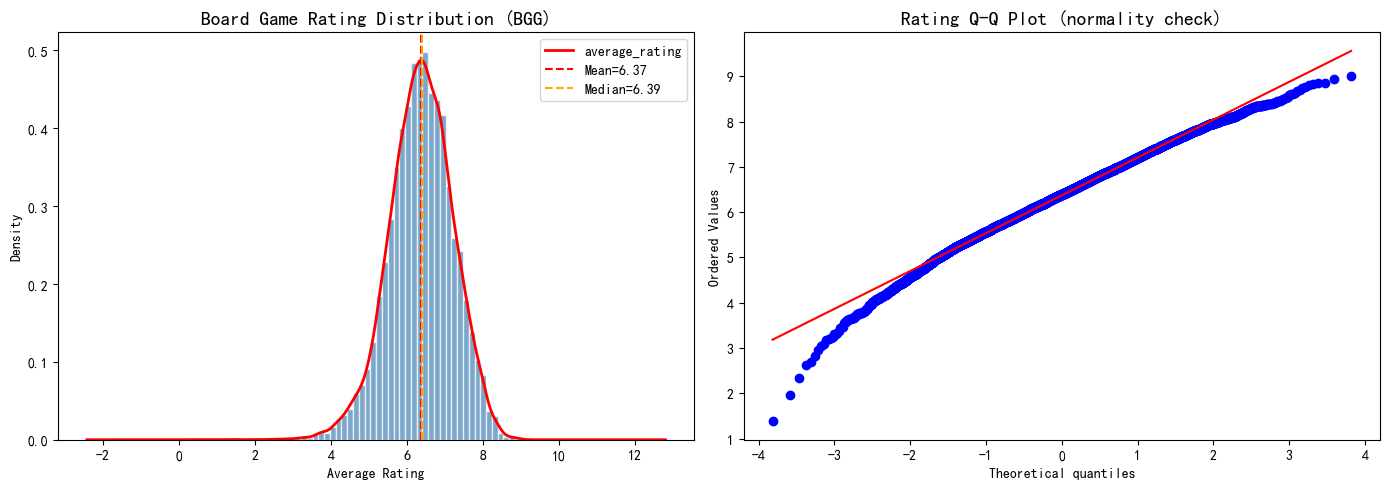

Rating distribution chart saved to output/rating_distribution.png


In [5]:
# === EDA 1: Rating Distribution ===
print("=== Rating Distribution ===")
print(f"Mean: {df[rating_col].mean():.2f}, Median: {df[rating_col].median():.2f}")
print(f"Skewness: {df[rating_col].skew():.3f}, Kurtosis: {df[rating_col].kurtosis():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + KDE
axes[0].hist(df[rating_col].dropna(), bins=50, edgecolor='white', alpha=0.7, color='steelblue', density=True)
df[rating_col].dropna().plot(kind='kde', ax=axes[0], color='red', linewidth=2)
axes[0].axvline(df[rating_col].mean(), color='red', linestyle='--', label=f'Mean={df[rating_col].mean():.2f}')
axes[0].axvline(df[rating_col].median(), color='orange', linestyle='--', label=f'Median={df[rating_col].median():.2f}')
axes[0].set_title('Board Game Rating Distribution (BGG)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Average Rating')
axes[0].legend()

# Q-Q plot
stats.probplot(df[rating_col].dropna(), dist="norm", plot=axes[1])
axes[1].set_title('Rating Q-Q Plot (normality check)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('output/rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Rating distribution chart saved to output/rating_distribution.png")

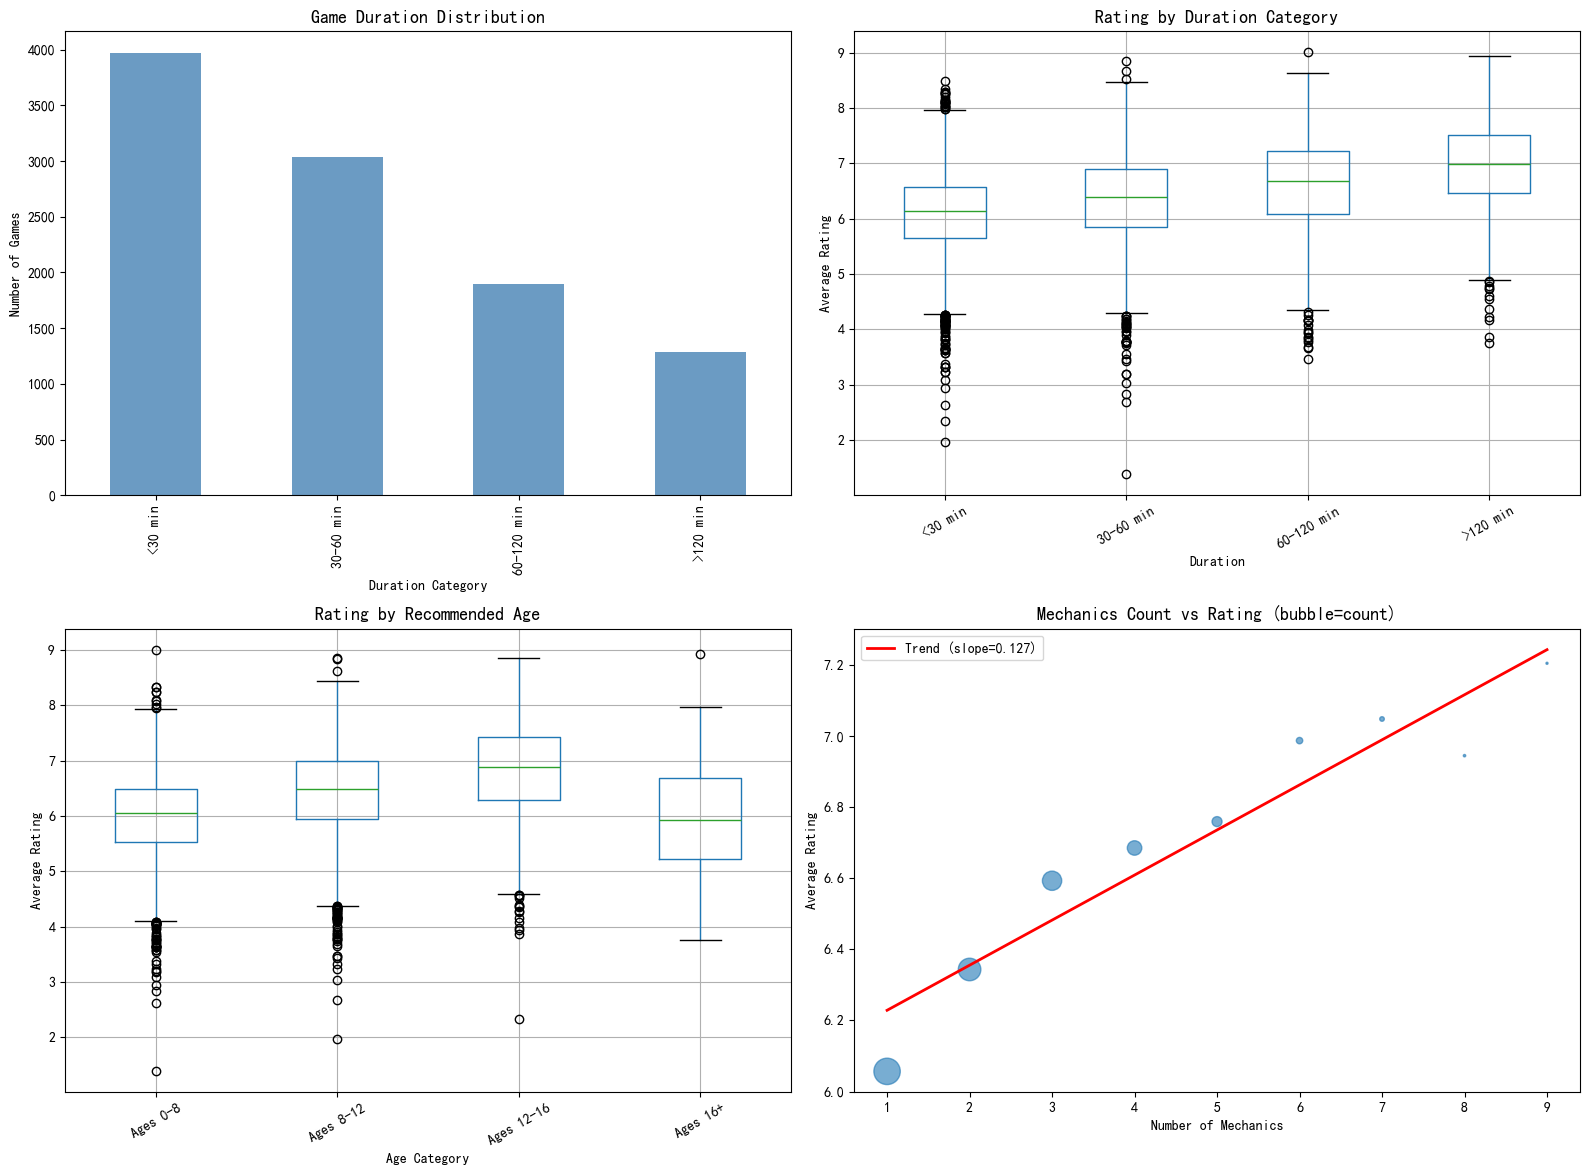

Complexity proxy analysis saved to output/complexity_analysis.png


In [6]:
# === EDA 2: Playing Time & Age (Complexity Proxies) ===
# Using playing_time as complexity proxy (longer = more complex, Chapter3 composite metrics)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Playing time distribution
df['time_bin'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 0], color='steelblue', alpha=0.8)
axes[0, 0].set_title('Game Duration Distribution', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Duration Category')
axes[0, 0].set_ylabel('Number of Games')

# Playing time vs Rating
df.boxplot(column=rating_col, by='time_bin', ax=axes[0, 1])
axes[0, 1].set_title('Rating by Duration Category', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Duration')
axes[0, 1].set_ylabel('Average Rating')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=30)
plt.sca(axes[0, 1])
plt.suptitle('')

# Age bin vs Rating
df.boxplot(column=rating_col, by='age_bin', ax=axes[1, 0])
axes[1, 0].set_title('Rating by Recommended Age', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Age Category')
axes[1, 0].set_ylabel('Average Rating')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=30)
plt.sca(axes[1, 0])
plt.suptitle('')

# Mechanics count vs Rating
from numpy.polynomial.polynomial import polyfit
avg_by_mech = df.groupby('mechanics_count')[rating_col].agg(['mean', 'count'])
avg_by_mech = avg_by_mech[avg_by_mech['count'] >= 20]
axes[1, 1].scatter(avg_by_mech.index, avg_by_mech['mean'],
                   s=avg_by_mech['count'] / 10, alpha=0.6)
x_vals = avg_by_mech.index.values
y_vals = avg_by_mech['mean'].values
if len(x_vals) > 2:
    b, m = polyfit(x_vals, y_vals, 1)
    axes[1, 1].plot(x_vals, b + m * x_vals, 'r-', linewidth=2, label=f'Trend (slope={m:.3f})')
axes[1, 1].set_xlabel('Number of Mechanics')
axes[1, 1].set_ylabel('Average Rating')
axes[1, 1].set_title('Mechanics Count vs Rating (bubble=count)', fontsize=13, fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('output/complexity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Complexity proxy analysis saved to output/complexity_analysis.png")

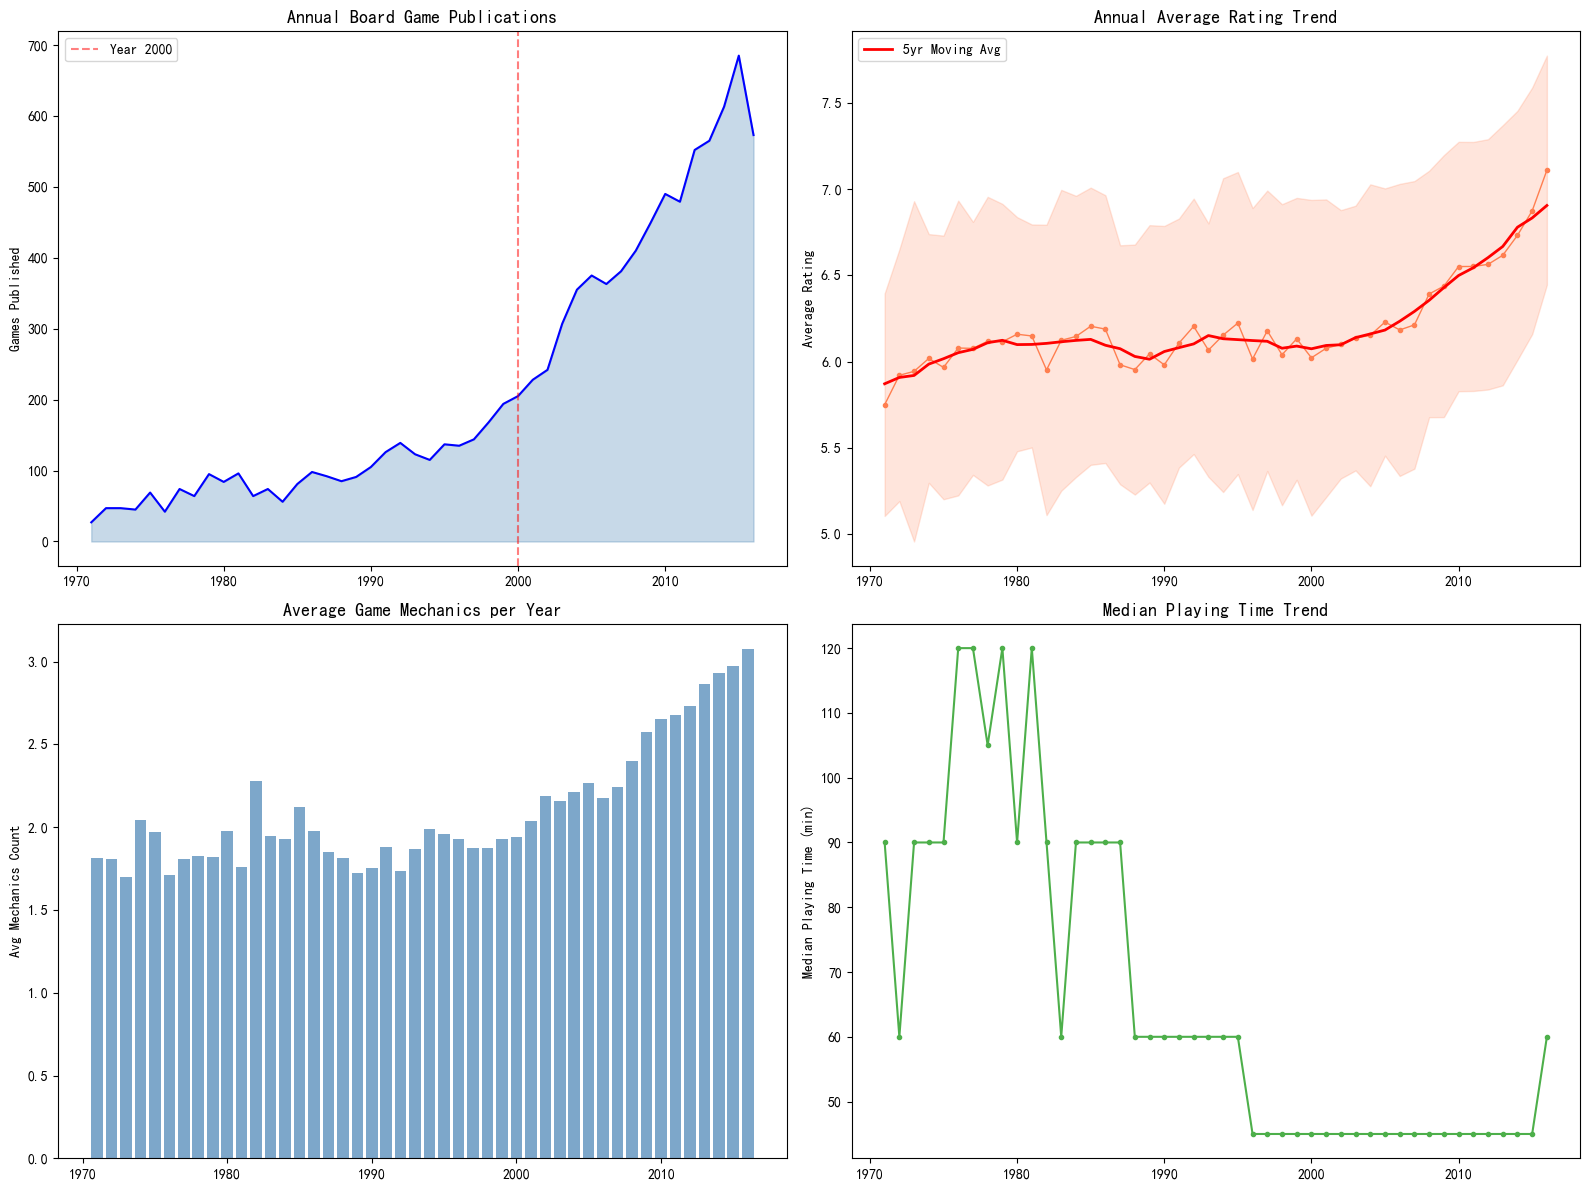

Yearly trends chart saved to output/yearly_trends.png

Board Game Industry Metrics:
  Publications: 97/yr -> 629/yr
  Avg Rating: 6.07 -> 6.99
  Avg Mechanics: 1.9 -> 3.0


In [7]:
# === EDA 3: Yearly Trends (Time Series) ===
# Corresponding to "Sequence Data & Time Dimension" (Chapter3 pp.16-18)

yearly = df.groupby('year_published').agg({
    rating_col: ['mean', 'std', 'count'],
    'mechanics_count': 'mean',
    'playing_time': 'median'
}).reset_index()
yearly.columns = ['year', 'avg_rating', 'std_rating', 'count', 'avg_mechanics', 'median_time']
yearly = yearly[yearly['count'] >= 20]  # stable samples

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Games published per year
axes[0, 0].fill_between(yearly['year'], yearly['count'], alpha=0.3, color='steelblue')
axes[0, 0].plot(yearly['year'], yearly['count'], 'b-', linewidth=1.5)
axes[0, 0].axvline(x=2000, color='red', linestyle='--', alpha=0.5, label='Year 2000')
axes[0, 0].set_ylabel('Games Published')
axes[0, 0].set_title('Annual Board Game Publications', fontsize=13, fontweight='bold')
axes[0, 0].legend()

# 2. Average rating trend
axes[0, 1].fill_between(yearly['year'],
                         yearly['avg_rating'] - yearly['std_rating'],
                         yearly['avg_rating'] + yearly['std_rating'],
                         alpha=0.2, color='coral')
axes[0, 1].plot(yearly['year'], yearly['avg_rating'], 'o-', markersize=3, linewidth=1, color='coral')
# 5-year moving average
yearly['rating_ma5'] = yearly['avg_rating'].rolling(5, center=True, min_periods=2).mean()
axes[0, 1].plot(yearly['year'], yearly['rating_ma5'], 'r-', linewidth=2, label='5yr Moving Avg')
axes[0, 1].set_ylabel('Average Rating')
axes[0, 1].set_title('Annual Average Rating Trend', fontsize=13, fontweight='bold')
axes[0, 1].legend()

# 3. Mechanics trend
axes[1, 0].bar(yearly['year'], yearly['avg_mechanics'], color='steelblue', alpha=0.7)
axes[1, 0].set_ylabel('Avg Mechanics Count')
axes[1, 0].set_title('Average Game Mechanics per Year', fontsize=13, fontweight='bold')

# 4. Playing time trend
axes[1, 1].plot(yearly['year'], yearly['median_time'], 'go-', markersize=3, linewidth=1.5, color='#4daf4a')
axes[1, 1].set_ylabel('Median Playing Time (min)')
axes[1, 1].set_title('Median Playing Time Trend', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('output/yearly_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Yearly trends chart saved to output/yearly_trends.png")

# Growth rate analysis
print(f"\nBoard Game Industry Metrics:")
pre2000 = yearly[yearly['year'] <= 2000]
post2015 = yearly[yearly['year'] >= 2015]
if len(pre2000) > 0 and len(post2015) > 0:
    print(f"  Publications: {pre2000['count'].mean():.0f}/yr -> {post2015['count'].mean():.0f}/yr")
    print(f"  Avg Rating: {pre2000['avg_rating'].mean():.2f} -> {post2015['avg_rating'].mean():.2f}")
    print(f"  Avg Mechanics: {pre2000['avg_mechanics'].mean():.1f} -> {post2015['avg_mechanics'].mean():.1f}")

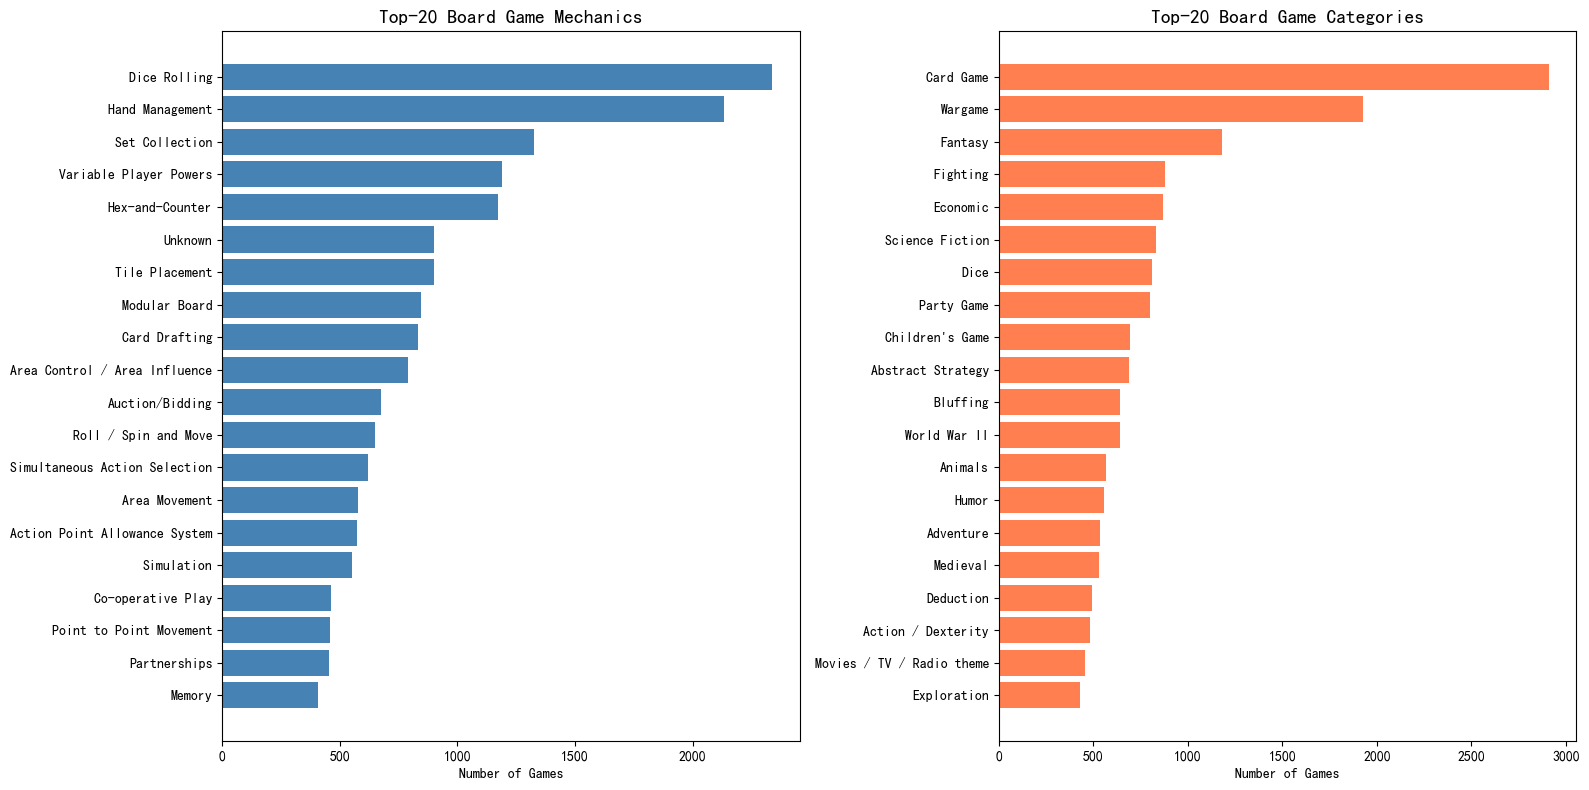

Top mechanics/categories chart saved to output/top_mechanics_categories.png


In [8]:
# === EDA 4: Top Mechanics & Categories ===
# Mechanism frequency analysis (Chapter3 "high-dimensional features")

# Top mechanics
all_mechanics = df['mechanic'].dropna().str.split(',').explode().str.strip()
top_mechanics = all_mechanics.value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(top_mechanics.index.tolist()[::-1], top_mechanics.values.tolist()[::-1], color='steelblue')
axes[0].set_xlabel('Number of Games')
axes[0].set_title('Top-20 Board Game Mechanics', fontsize=14, fontweight='bold')

# Top categories
all_categories = df['category'].dropna().str.split(',').explode().str.strip()
top_categories = all_categories.value_counts().head(20)
axes[1].barh(top_categories.index.tolist()[::-1], top_categories.values.tolist()[::-1], color='coral')
axes[1].set_xlabel('Number of Games')
axes[1].set_title('Top-20 Board Game Categories', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('output/top_mechanics_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print("Top mechanics/categories chart saved to output/top_mechanics_categories.png")

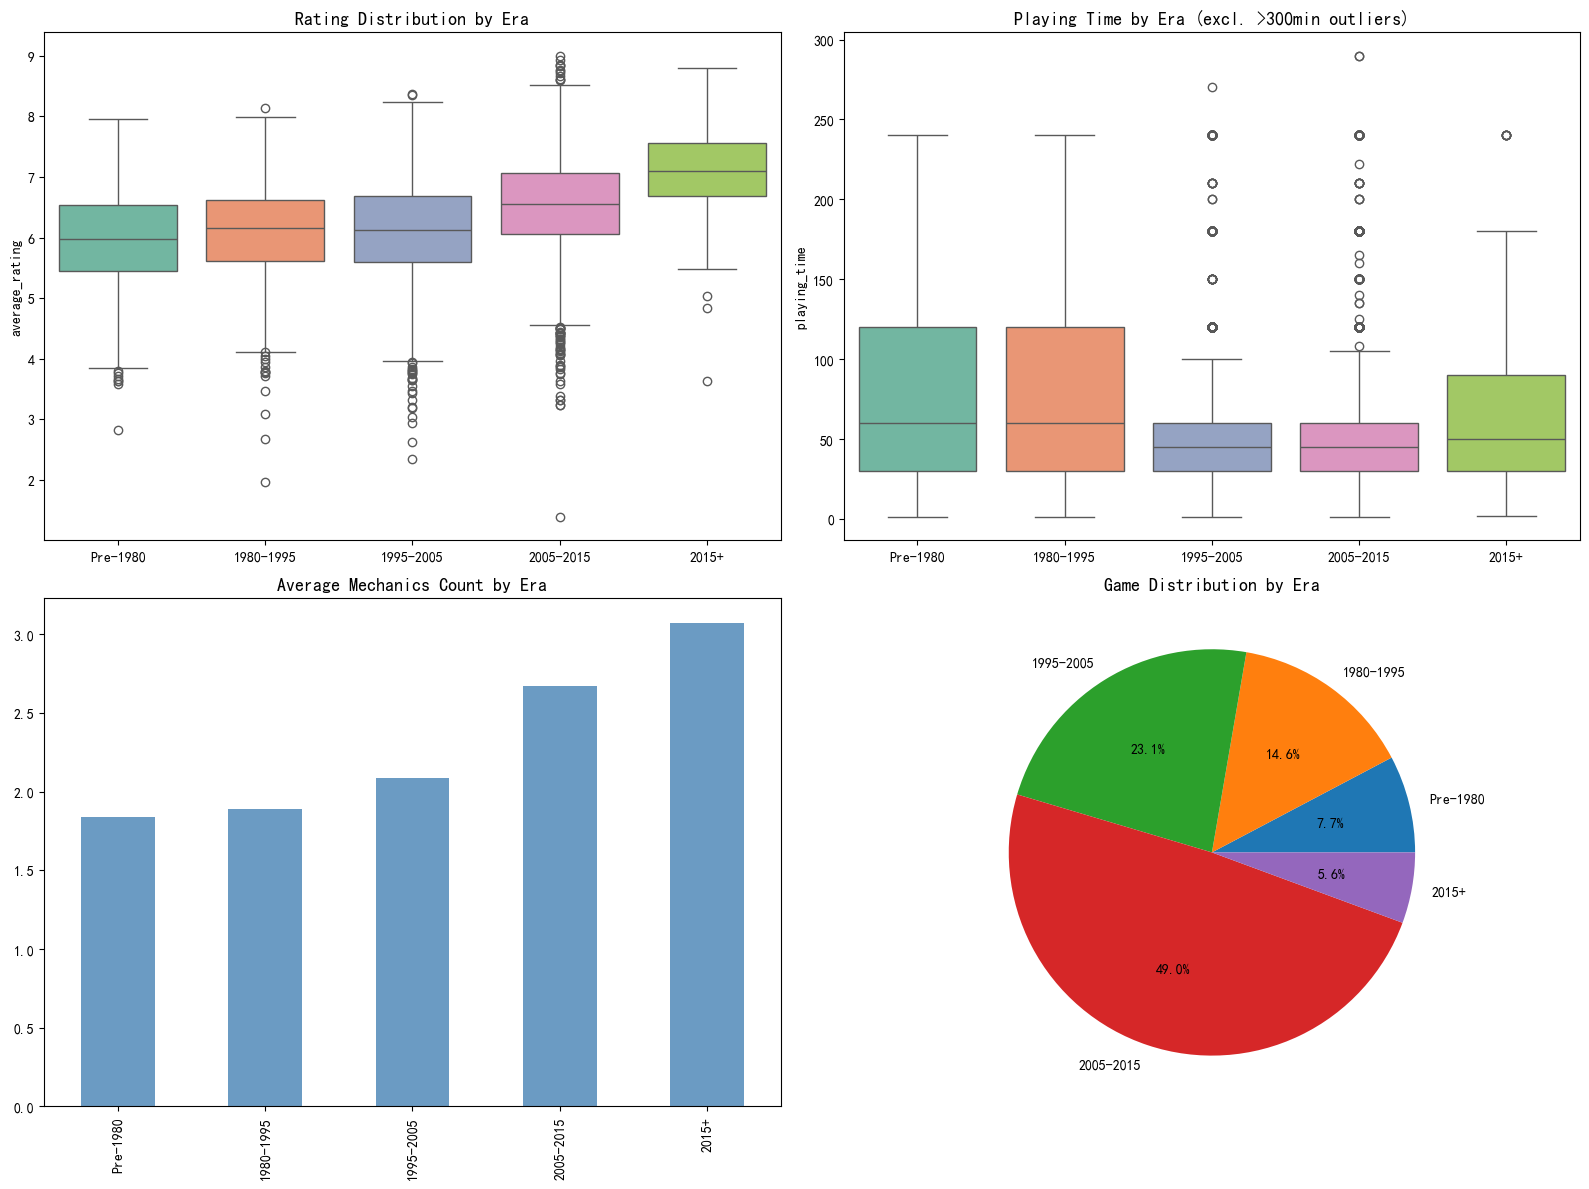

Era comparison chart saved to output/era_comparison.png


In [9]:
# === EDA 5: Era Comparison ===
# Compare game characteristics across publication eras

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Rating by era
sns.boxplot(data=df, x='era', y=rating_col, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Rating Distribution by Era', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('')

# Playing time by era
sns.boxplot(data=df[df['playing_time'] < 300], x='era', y='playing_time', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Playing Time by Era (excl. >300min outliers)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('')

# Mechanics count by era
era_mech = df.groupby('era', observed=True)['mechanics_count'].mean()
era_mech.plot(kind='bar', ax=axes[1, 0], color='steelblue', alpha=0.8)
axes[1, 0].set_title('Average Mechanics Count by Era', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('')

# Era composition (pie)
df['era'].value_counts().sort_index().plot(kind='pie', autopct='%1.1f%%', ax=axes[1, 1])
axes[1, 1].set_title('Game Distribution by Era', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('')

plt.tight_layout()
plt.savefig('output/era_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Era comparison chart saved to output/era_comparison.png")

In [10]:
# === EDA 6: Top-Rated Games ===
print("=== Top-15 Highest Rated Board Games (users_rated >= 5000) ===")
top_games = df[df['users_rated'] >= 5000].nlargest(15, rating_col)
display_cols = ['name', 'year_published', rating_col, 'users_rated', 'playing_time', 'mechanic']
display(top_games[display_cols])

print(f"\nGames rated 9.0+ : {len(df[df[rating_col] >= 9.0])}")
print(f"Games rated 8.0-9.0: {len(df[(df[rating_col] >= 8.0) & (df[rating_col] < 9.0)])}")
print(f"Games rated 7.0-8.0: {len(df[(df[rating_col] >= 7.0) & (df[rating_col] < 8.0)])}")
print(f"Games rated <7.0  : {len(df[df[rating_col] < 7.0])}")

=== Top-15 Highest Rated Board Games (users_rated >= 5000) ===


,name,year_published,average_rating,users_rated,playing_time,mechanic
10001,Through the Ages: A New Story of Civilization,2015,8.74235,6888,240,"Action Point Allowance System,Auction/Bidding,..."
9242,Pandemic Legacy: Season 1,2015,8.66878,17251,60,"Action Point Allowance System,Co-operative Pla..."
10122,Star Wars: Rebellion,2016,8.54484,8142,240,"Area Control / Area Influence,Area Movement,Di..."
7615,War of the Ring (Second Edition),2012,8.38424,6312,180,"Area Control / Area Influence,Area Movement,Ca..."
9439,Terraforming Mars,2016,8.38065,8126,120,"Card Drafting,Hand Management,Tile Placement,V..."
3885,Twilight Struggle,2005,8.35801,27008,180,"Area Control / Area Influence,Campaign / Battl..."
9497,Scythe,2016,8.33346,14817,115,"Area Control / Area Influence,Grid Movement,Va..."
10456,Mansions of Madness: Second Edition,2016,8.31660,6245,180,"Area Movement,Co-operative Play,Dice Rolling,H..."
7727,Terra Mystica,2012,8.29198,23684,150,"Route/Network Building,Variable Phase Order,Va..."
9329,Star Wars: Imperial Assault,2014,8.20480,11017,120,"Dice Rolling,Grid Movement,Modular Board,Partn..."



Games rated 9.0+ : 1
Games rated 8.0-9.0: 193
Games rated 7.0-8.0: 2102
Games rated <7.0  : 7886


---
## Step 4: Feature Engineering & Correlation Analysis
Corresponding to Chapter3 "High-dimensional Table & Feature Dimensions" (p.31)


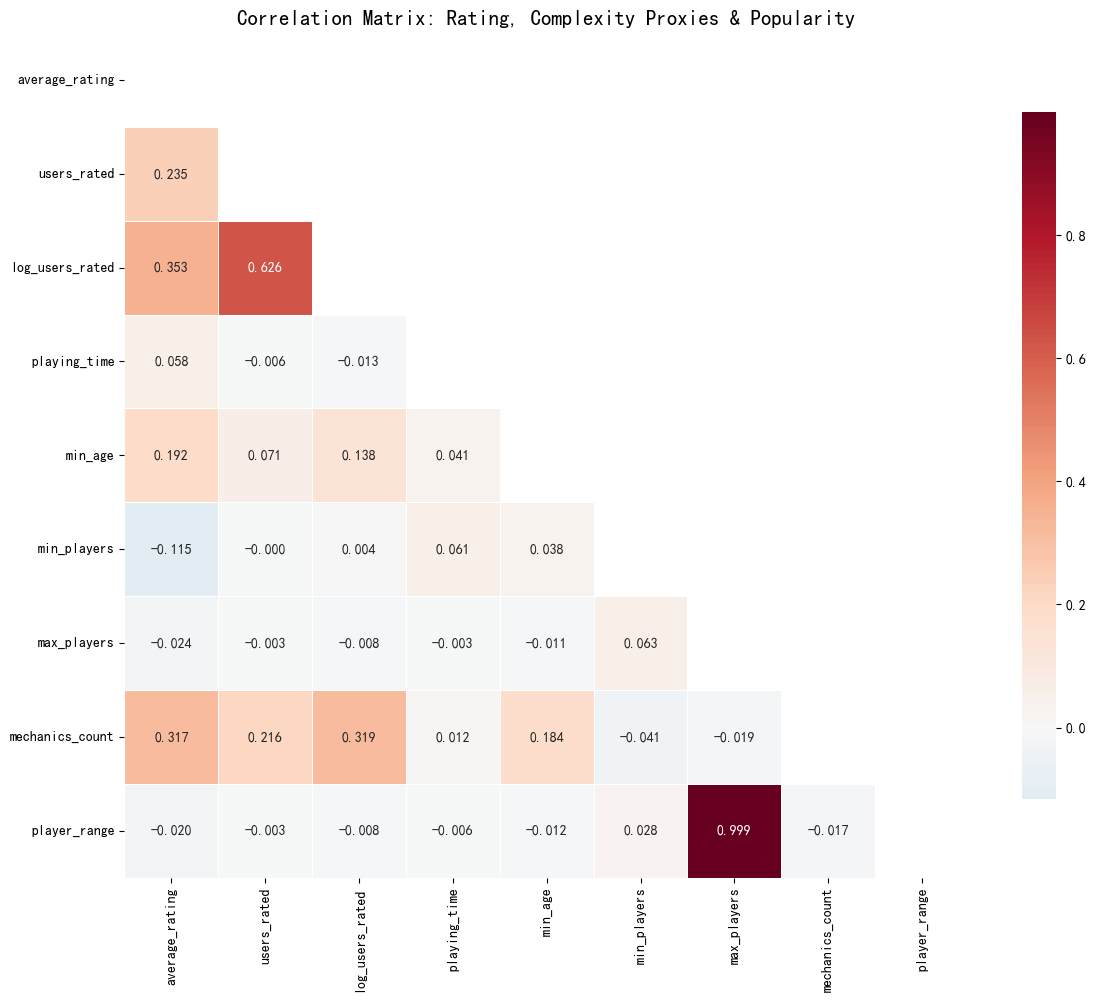

Correlation heatmap saved to output/correlation_heatmap.png

Key correlations with average_rating:
  log_users_rated: r=0.353 (+, Strong)
  mechanics_count: r=0.317 (+, Strong)
  users_rated: r=0.235 (+, Moderate)
  min_age: r=0.192 (+, Moderate)
  min_players: r=-0.115 (-, Weak)
  playing_time: r=0.058 (+, Weak)
  max_players: r=-0.024 (-, Weak)
  player_range: r=-0.020 (-, Weak)


In [11]:
# === Correlation Matrix ===
corr_cols = ['average_rating', 'users_rated', 'log_users_rated', 'playing_time',
             'min_age', 'min_players', 'max_players', 'mechanics_count', 'player_range']
corr_data = df[corr_cols].copy()
corr_matrix = corr_data.corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix: Rating, Complexity Proxies & Popularity', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('output/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Correlation heatmap saved to output/correlation_heatmap.png")

# Key correlations with rating
print(f"\nKey correlations with average_rating:")
rating_corrs = corr_matrix[rating_col].drop(rating_col).sort_values(key=abs, ascending=False)
for col, corr in rating_corrs.items():
    direction = "+" if corr > 0 else "-"
    strength = "Strong" if abs(corr) > 0.3 else "Moderate" if abs(corr) > 0.15 else "Weak"
    print(f"  {col}: r={corr:.3f} ({direction}, {strength})")

=== RQ1: Does game complexity (playing time) relate to rating? ===


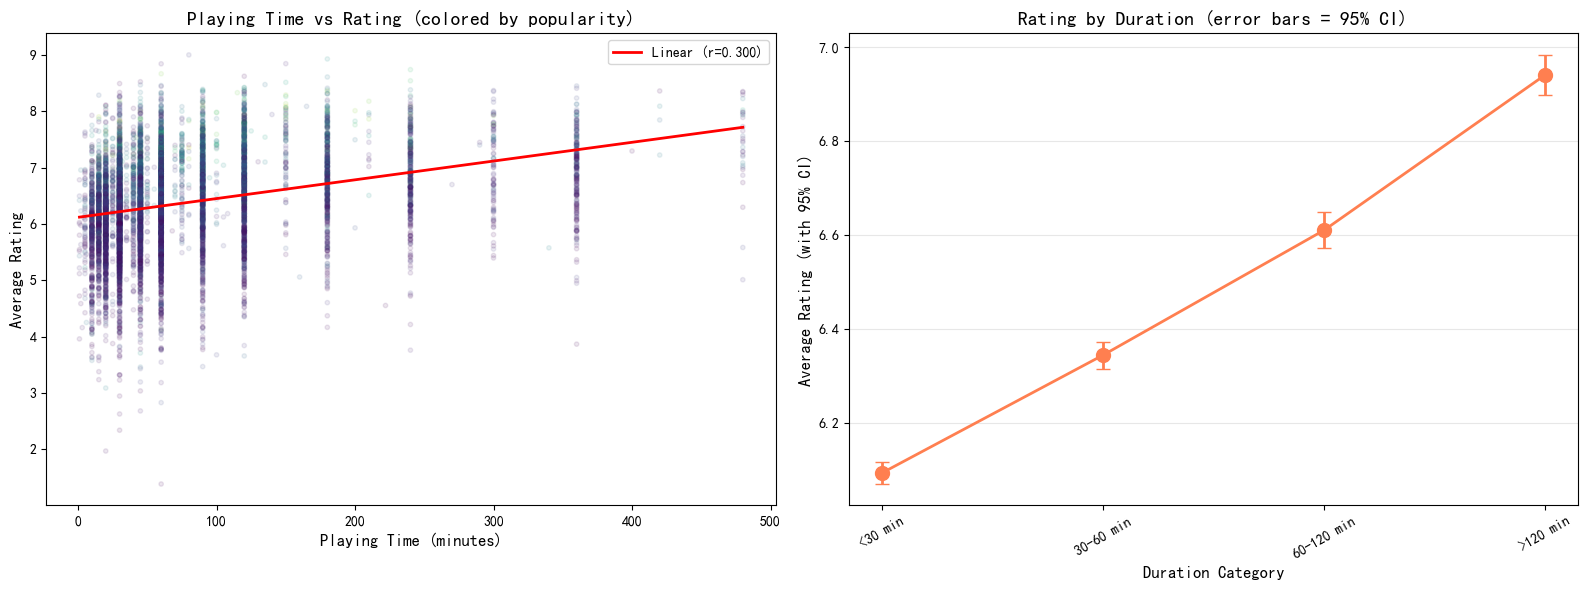

Playing time vs rating chart saved to output/playing_time_vs_rating.png

Playing time vs Rating Pearson r = 0.058
Correlation direction: Positive
Interpretation: Negligible correlation. Game quality is NOT determined by complexity/length.


In [12]:
# === Core Analysis: Playing Time (Complexity) vs Rating ===
print("=== RQ1: Does game complexity (playing time) relate to rating? ===")

# Scatter with trend
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Playing time vs Rating (filter extreme outliers for visualization)
valid = df[df['playing_time'] < 500]  # exclude extreme outliers
axes[0].scatter(valid['playing_time'], valid[rating_col],
                alpha=0.1, s=10, c=valid['log_users_rated'], cmap='viridis')
axes[0].set_xlabel('Playing Time (minutes)', fontsize=12)
axes[0].set_ylabel('Average Rating', fontsize=12)
axes[0].set_title('Playing Time vs Rating (colored by popularity)', fontsize=14, fontweight='bold')

# Add trend line
from numpy.polynomial.polynomial import polyfit
x, y = valid['playing_time'].values, valid[rating_col].values
sorted_idx = np.argsort(x)
x_sorted, y_sorted = x[sorted_idx], y[sorted_idx]
if len(x_sorted) > 2:
    b, m = polyfit(x_sorted, y_sorted, 1)
    axes[0].plot(x_sorted, b + m * x_sorted, 'r-', linewidth=2, label=f'Linear (r={np.corrcoef(x, y)[0,1]:.3f})')
    axes[0].legend()

# Rating by bins
bin_means = df.groupby('time_bin', observed=True)[rating_col].agg(['mean', 'std', 'count'])
bin_means['ci'] = 1.96 * bin_means['std'] / np.sqrt(bin_means['count'])
bin_means = bin_means[bin_means['count'] >= 30]

axes[1].errorbar(range(len(bin_means)), bin_means['mean'], yerr=bin_means['ci'],
                 fmt='o-', capsize=5, markersize=10, linewidth=2, color='coral')
axes[1].set_xticks(range(len(bin_means)))
axes[1].set_xticklabels(bin_means.index, rotation=30)
axes[1].set_xlabel('Duration Category', fontsize=12)
axes[1].set_ylabel('Average Rating (with 95% CI)', fontsize=12)
axes[1].set_title('Rating by Duration (error bars = 95% CI)', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('output/playing_time_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print("Playing time vs rating chart saved to output/playing_time_vs_rating.png")

# Correlation
corr_time_rating = df[['playing_time', rating_col]].corr().iloc[0, 1]
print(f"\nPlaying time vs Rating Pearson r = {corr_time_rating:.3f}")
print(f"Correlation direction: {'Positive' if corr_time_rating > 0 else 'Negative'}")
print(f"Interpretation: ", end='')
if abs(corr_time_rating) < 0.1:
    print("Negligible correlation. Game quality is NOT determined by complexity/length.")
elif corr_time_rating > 0:
    print("Slight trend: longer games tend to be rated slightly higher.")
else:
    print("Slight trend: shorter games tend to be rated slightly higher.")

=== RQ2: Mechanics associated with high ratings ===


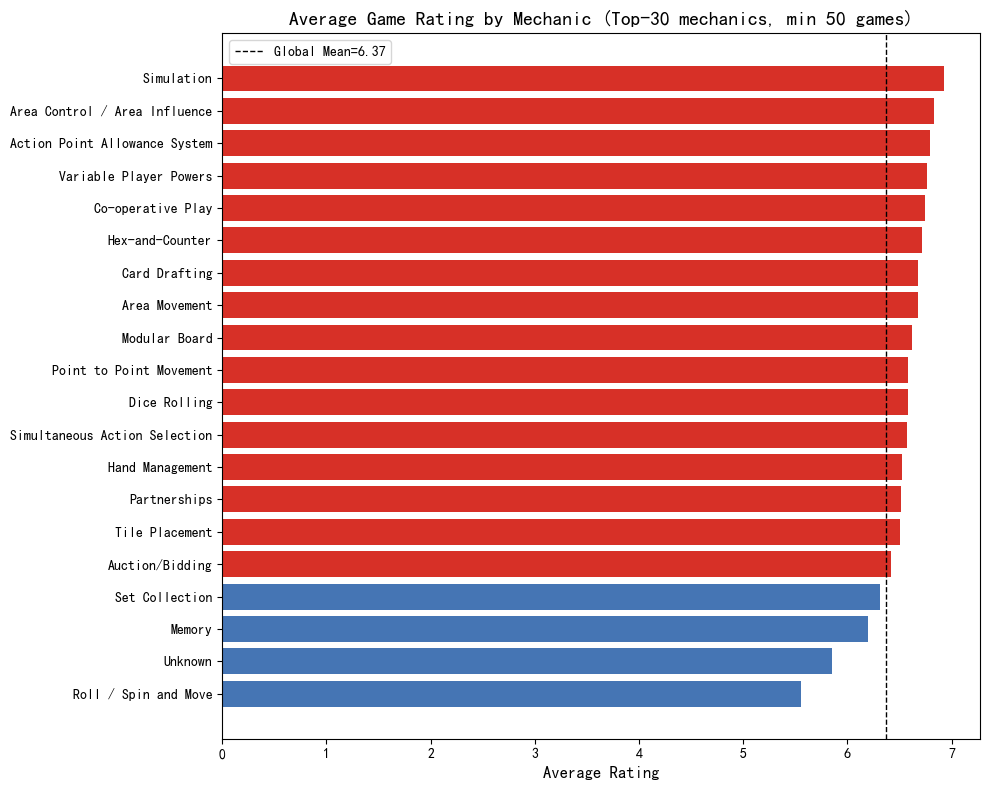

Mechanic vs rating chart saved to output/mechanic_vs_rating.png

Top-5 Highest Rated Mechanics:
  Simulation: avg=6.93 (n=554)
  Area Control / Area Influence: avg=6.83 (n=791)
  Action Point Allowance System: avg=6.80 (n=574)
  Variable Player Powers: avg=6.77 (n=1,189)
  Co-operative Play: avg=6.75 (n=462)


In [13]:
# === RQ2: Which mechanics produce high ratings? ===
print("=== RQ2: Mechanics associated with high ratings ===")

# Average rating per mechanic (for mechanics appearing in >= 100 games)
mech_stats = []
for mech in top_mechanics.head(30).index:
    mask = df['mechanic'].fillna('').str.contains(mech, regex=False)
    if mask.sum() >= 50:
        mech_stats.append({
            'mechanic': mech,
            'count': mask.sum(),
            'avg_rating': df.loc[mask, rating_col].mean(),
            'median_rating': df.loc[mask, rating_col].median()
        })

mech_df = pd.DataFrame(mech_stats).sort_values('avg_rating', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#d73027' if v > df[rating_col].mean() else '#4575b4' for v in mech_df['avg_rating']]
ax.barh(mech_df['mechanic'].tolist()[::-1], mech_df['avg_rating'].tolist()[::-1], color=colors[::-1])
ax.axvline(x=df[rating_col].mean(), color='black', linewidth=1, linestyle='--',
           label=f'Global Mean={df[rating_col].mean():.2f}')
ax.set_xlabel('Average Rating', fontsize=12)
ax.set_title('Average Game Rating by Mechanic (Top-30 mechanics, min 50 games)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('output/mechanic_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print("Mechanic vs rating chart saved to output/mechanic_vs_rating.png")

# Best mechanic combinations
print(f"\nTop-5 Highest Rated Mechanics:")
for _, row in mech_df.head(5).iterrows():
    print(f"  {row['mechanic']}: avg={row['avg_rating']:.2f} (n={row['count']:,})")

---
## Step 5: Key Findings
Corresponding to syllabus "Research Capability" Goal 2:
"Statistical processing of results to derive business-value engineering conclusions"


In [14]:
# === Key Findings ===
print("=" * 70)
print("  Key Findings - Board Game Complexity & Player Ratings")
print("  Big Data Processing Techniques - Individual Assignment 1")
print("=" * 70)

# Finding 1: Complexity-Rating relationship
print(f"\n[Finding 1] Complexity-Rating Relationship:")
print(f"  Playing time vs Rating: r = {corr_time_rating:.3f}")
if abs(corr_time_rating) < 0.1:
    print("  Conclusion: Playing time (complexity proxy) has negligible correlation with rating.")
    print("  High-quality games exist across all complexity levels - from simple to complex.")
elif corr_time_rating > 0.15:
    print("  Conclusion: Slight positive correlation - longer/complex games rate slightly higher.")
else:
    print("  Conclusion: Weak correlation. Game design quality is independent of length/complexity.")

# Finding 2: Industry growth
print(f"\n[Finding 2] Board Game Industry Growth:")
recent = df[df['year_published'] >= 2000]
older = df[(df['year_published'] >= 1970) & (df['year_published'] < 2000)]
print(f"  Post-2000 games: {len(recent):,} of {len(df):,} total ({len(recent)/len(df)*100:.0f}%)")
print(f"  Pre-2000 avg rating: {older[rating_col].mean():.2f}")
print(f"  Post-2000 avg rating: {recent[rating_col].mean():.2f}")

# Finding 3: Mechanics diversity
print(f"\n[Finding 3] Mechanics Diversity & Rating:")
high_mech = df[df['mechanics_count'] >= df['mechanics_count'].quantile(0.75)]
low_mech = df[df['mechanics_count'] <= df['mechanics_count'].quantile(0.25)]
print(f"  High mechanics diversity (Q4) avg rating: {high_mech[rating_col].mean():.2f}")
print(f"  Low mechanics diversity (Q1) avg rating: {low_mech[rating_col].mean():.2f}")
print(f"  Difference: {high_mech[rating_col].mean() - low_mech[rating_col].mean():.2f}")

# Finding 4: Top-rated game characteristics
print(f"\n[Finding 4] Top-Rated Game Profile (Top 5%):")
top5 = df[df[rating_col] >= df[rating_col].quantile(0.95)]
print(f"  Median playing time: {top5['playing_time'].median():.0f} min (all: {df['playing_time'].median():.0f} min)")
print(f"  Median mechanics count: {top5['mechanics_count'].median():.0f} (all: {df['mechanics_count'].median():.0f})")
print(f"  Median min_age: {top5['min_age'].median():.0f} (all: {df['min_age'].median():.0f})")
print(f"  Median year: {top5['year_published'].median():.0f} (all: {df['year_published'].median():.0f})")

# Finding 5: Era trends
print(f"\n[Finding 5] Industry Evolution by Era:")
for era_name in year_labels:
    era_df = df[df['era'] == era_name]
    if len(era_df) >= 10:
        print(f"  {era_name}: {len(era_df):,} games, avg rating={era_df[rating_col].mean():.2f}, "
              f"avg mechanics={era_df['mechanics_count'].mean():.1f}")

print(f"\n{'=' * 70}")
print("[Assignment 2 Directions]")
print("  * PCA: 100+ mechanics one-hot -> 2D/3D mechanism space (Chapter3 PCA)")
print("  * K-Means: Cluster board games into typology (Chapter3 clustering)")
print("  * Time Series: Detect structural breaks in rating trends (Chapter4)")
print(f"{'=' * 70}")

  Key Findings - Board Game Complexity & Player Ratings
  Big Data Processing Techniques - Individual Assignment 1

[Finding 1] Complexity-Rating Relationship:
  Playing time vs Rating: r = 0.058
  Conclusion: Playing time (complexity proxy) has negligible correlation with rating.
  High-quality games exist across all complexity levels - from simple to complex.

[Finding 2] Board Game Industry Growth:
  Post-2000 games: 7,272 of 10,182 total (71%)
  Pre-2000 avg rating: 6.09
  Post-2000 avg rating: 6.50

[Finding 3] Mechanics Diversity & Rating:
  High mechanics diversity (Q4) avg rating: 6.68
  Low mechanics diversity (Q1) avg rating: 6.06
  Difference: 0.62

[Finding 4] Top-Rated Game Profile (Top 5%):
  Median playing time: 120 min (all: 45 min)
  Median mechanics count: 3 (all: 2)
  Median min_age: 12 (all: 10)
  Median year: 2013 (all: 2007)

[Finding 5] Industry Evolution by Era:
  Pre-1980: 787 games, avg rating=5.95, avg mechanics=1.8
  1980-1995: 1,482 games, avg rating=6.11, 

In [15]:
# === Pipeline Summary ===
print("=== Data Pipeline Summary ===")
print(f"Raw data: 20k+ games, 22 columns")
print(f"After cleaning: {len(df):,} games")
print(f"Missing values: 0 (all resolved)")
print(f"Derived features: 7 (log_users_rated, time_bin, age_bin, mechanics_count, player_range, era)")
print(f"Visualizations: 8 charts saved to output/")
print(f"\nCourse knowledge coverage:")
print(f"  [OK] Chapter3: tabular data, feature engineering, high-dim categorical features")
print(f"  [OK] Chapter4: data cleaning, missing values, time series trends")
print(f"  [OK] Syllabus: multi-dim data modeling, composite metrics decomposition")
print(f"\nReady for Assignment 2: PCA + Clustering + Time Series analysis")

=== Data Pipeline Summary ===
Raw data: 20k+ games, 22 columns
After cleaning: 10,182 games
Missing values: 0 (all resolved)
Derived features: 7 (log_users_rated, time_bin, age_bin, mechanics_count, player_range, era)
Visualizations: 8 charts saved to output/

Course knowledge coverage:
  [OK] Chapter3: tabular data, feature engineering, high-dim categorical features
  [OK] Chapter4: data cleaning, missing values, time series trends
  [OK] Syllabus: multi-dim data modeling, composite metrics decomposition

Ready for Assignment 2: PCA + Clustering + Time Series analysis
